In [ ]:
import os
import sys
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from scipy import sparse
from datetime import datetime

from onehot_encoder import onehot_encoder_pipeline, TorchData, TorchNetModel, train_model


In [13]:
"""dataset.columns:
'age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'
"""

target_col = 'y'     # does client have account/deposits
drop_cols = [
    'month', 'day_of_week', 'emp_var_rate', 
    'cons_price_idx', 'cons_conf_idx', 
    'euribor3m', 'nr_employed'
]
categorical_cols = [
    'job', 'marital', 'education', 'default', 
    'housing', 'loan', 'contact', 'poutcome'
]
SCATTER_PLOT = True
SAVE_MODEL = False

try:
    data_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), '..', 'data'))
except NameError:
    data_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
sys.path.append(data_dir)


In [ ]:

dataset = pd.read_csv(os.path.join(data_dir, 'bank.csv'))
df = dataset.drop(columns=drop_cols)

X = df.drop(columns=[target_col])
y = df[target_col].values
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()


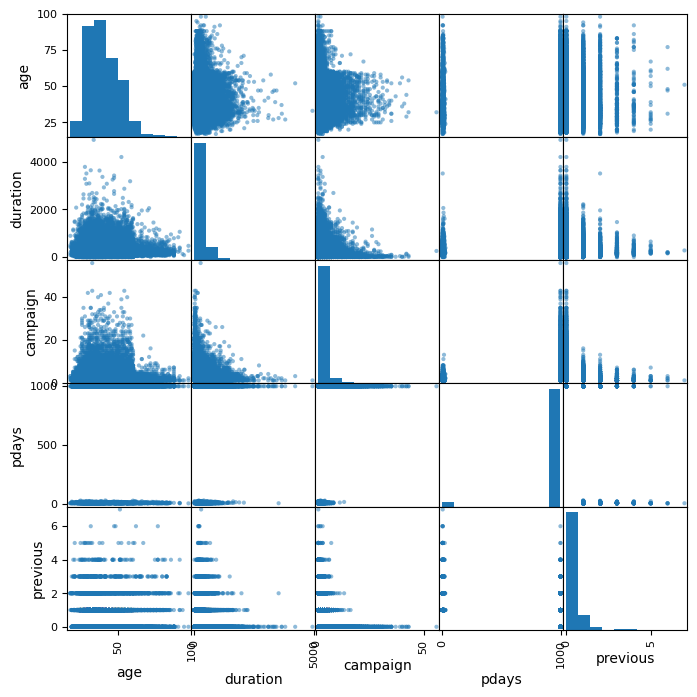

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,y
0,44,blue-collar,married,basic.4y,unknown,yes,no,cellular,210,1,999,0,nonexistent,0
1,53,technician,married,unknown,no,no,no,cellular,138,1,999,0,nonexistent,0
2,28,management,single,university.degree,no,yes,no,cellular,339,3,6,2,success,1
3,39,services,married,high.school,no,no,no,cellular,185,2,999,0,nonexistent,0
4,55,retired,married,basic.4y,no,yes,no,cellular,137,1,3,1,success,1
5,30,management,divorced,basic.4y,no,yes,no,cellular,68,8,999,0,nonexistent,0
6,37,blue-collar,married,basic.4y,no,yes,no,cellular,204,1,999,0,nonexistent,0
7,39,blue-collar,divorced,basic.9y,no,yes,no,cellular,191,1,999,0,nonexistent,0
8,36,admin.,married,university.degree,no,no,no,cellular,174,1,3,1,success,1
9,27,blue-collar,single,basic.4y,no,yes,no,cellular,191,2,999,1,failure,0


In [ ]:

if SCATTER_PLOT:
    pd.plotting.scatter_matrix(df[numeric_cols], figsize=(8, 8))
    plt.show()
df.head(10)


In [ ]:

# apply preprocessor pipeline
preprocessor = onehot_encoder_pipeline(categorical_cols, numeric_cols)
X_processed = preprocessor.fit_transform(X)
if sparse.issparse(X_processed):
    X_processed = X_processed.toarray()  # Convert sparse matrix to dense if needed

# Convert to tensors
X_tensor = torch.tensor(X_processed, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
X_train, X_val, y_train, y_val = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

# Create data and loaders for training and validation
train_dataset = TorchData(X_train, y_train)
val_dataset = TorchData(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


Epoch 1/10, Train Loss: 255.6165, Val Loss: 58.8330, Val Acc: 0.9017
Epoch 2/10, Train Loss: 231.0524, Val Loss: 58.6829, Val Acc: 0.9020
Epoch 3/10, Train Loss: 228.3208, Val Loss: 58.6043, Val Acc: 0.9018
Epoch 4/10, Train Loss: 226.8693, Val Loss: 58.4468, Val Acc: 0.9036
Epoch 5/10, Train Loss: 225.9565, Val Loss: 58.2119, Val Acc: 0.9028
Epoch 6/10, Train Loss: 224.9874, Val Loss: 58.9752, Val Acc: 0.9050
Epoch 7/10, Train Loss: 224.4089, Val Loss: 58.8831, Val Acc: 0.9048
Epoch 8/10, Train Loss: 223.7849, Val Loss: 59.2513, Val Acc: 0.9047
Epoch 9/10, Train Loss: 222.2776, Val Loss: 61.0287, Val Acc: 0.8977
Epoch 10/10, Train Loss: 222.3447, Val Loss: 58.8981, Val Acc: 0.9023


BankModel(
  (net): Sequential(
    (0): Linear(in_features=43, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

In [ ]:

model = TorchNetModel(X_tensor.shape[1])
train_model(model, train_loader, val_loader, val_dataset)

# Optionally save the model
if SAVE_MODEL:
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    model_path = os.path.join(data_dir, f'trained_bank_model_{timestamp}.pth')
    torch.save(model.state_dict(), model_path)
    print(f"✅ Model saved to: {model_path}")

Epoch 1/10, Train Loss: 251.9782, Val Loss: 58.9831, Val Acc: 0.9030
Epoch 2/10, Train Loss: 231.4288, Val Loss: 58.5606, Val Acc: 0.9047
Epoch 3/10, Train Loss: 228.9965, Val Loss: 58.8922, Val Acc: 0.9017
Epoch 4/10, Train Loss: 227.0497, Val Loss: 58.2649, Val Acc: 0.9052
Epoch 5/10, Train Loss: 226.0533, Val Loss: 59.5959, Val Acc: 0.9054
Epoch 6/10, Train Loss: 224.7784, Val Loss: 58.7062, Val Acc: 0.9036
Epoch 7/10, Train Loss: 224.0981, Val Loss: 58.4289, Val Acc: 0.9048
Epoch 8/10, Train Loss: 223.0420, Val Loss: 58.3636, Val Acc: 0.9054
Epoch 9/10, Train Loss: 222.1264, Val Loss: 58.2798, Val Acc: 0.9054
Epoch 10/10, Train Loss: 221.1604, Val Loss: 58.6107, Val Acc: 0.9050
